# An arbitrary Hamiltonian, through three profiles

The other notebooks vary one thing at a time. `03` puts a non-standard Hamiltonian through matter of **constant** density; `08` and `14` put the **standard** Hamiltonian through profiles that vary; `01` evaluates an arbitrary Hermitian matrix once. Nothing so far carries a Hamiltonian of your own through a profile that changes under it.

This notebook does, three times over — an invented body, an exponential one, and the Earth.

The worked case is a **long-range force**: a gauged $L_e - L_\mu$ symmetry with a very light mediator, following [arXiv:1808.02042](https://arxiv.org/abs/1808.02042). It is a good test of the machinery for one specific reason. $V_{CC}$ reads the density at the neutrino's own position; this potential integrates the electrons of the *whole body*, so it varies along a trajectory in a way that has nothing to do with the local density — and it cannot be expressed in the form the `earth` entry points build.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth
import slabs

## The Hamiltonian

Gauge $L_e - L_\mu$ and the mediator $Z'$ couples to that charge. Electrons carry $L_e = 1$, so ordinary matter is a source; among the neutrinos, $\nu_e$ carries $+1$, $\nu_\mu$ carries $-1$ and $\nu_\tau$ is neutral. So the new term enters the flavor basis as

$$ H = \underbrace{\frac{H_{\rm vac}}{E} + V_{CC}\,\mathrm{diag}(1,0,0)}_{\text{the standard part}} + V_{e\mu}(r)\,\mathrm{diag}(1,-1,0) , $$

with the potential a Yukawa integral over the electrons around the neutrino,

$$ V_{e\mu}(\mathbf{r}) = \frac{g'^2}{4\pi} \int d^3r' \, n_e(\mathbf{r}')\, \frac{e^{-m_{Z'}|\mathbf{r}-\mathbf{r}'|}}{|\mathbf{r}-\mathbf{r}'|} . $$

**This is the whole point of the notebook.** That matrix is not $H_{\rm vac}/E + V_{CC}P_{ee}$ for any $V_{CC}$, so `earth.probabilities_3nu_earth` — which builds exactly that form from a zenith angle — cannot produce it, however its arguments are chosen. The last section shows what to do instead.

**Scope.** Only the electrons of the body being crossed are counted; outside it, the electron density is taken to be zero. The reference adds the rest of the Universe, which dominates for a mediator lighter than these, and is a different calculation.

### The integral is one-dimensional

A $3n$-dimensional integral per slab would be hopeless. But for a spherically symmetric $n_e$ the angular average of the Yukawa kernel over a shell of radius $r'$ is elementary,

$$ \left\langle \frac{e^{-m d}}{d} \right\rangle_{\rm shell} = \frac{e^{-m|r-r'|} - e^{-m(r+r')}}{2 m r r'} , $$

and the result separates into an interior and an exterior piece:

$$ V_{e\mu}(r) = \frac{g'^2}{r}\left[ e^{-mr} \int_0^r dr'\, r'^2 n_e(r')\,\mathrm{shc}(m r') + r\,\mathrm{shc}(m r) \int_r^R dr'\, r' n_e(r')\, e^{-m r'} \right] $$

with $\mathrm{shc}(x) \equiv \sinh(x)/x$, which is $1$ at the origin. Two things follow, and both matter here. The $r$-dependence has left the integrands, so **one pass over the profile serves every point on the trajectory** — the potential is built once per body, not once per slab. And nothing diverges as $m \to 0$: the bracket becomes the enclosed-charge form of an ordinary $1/r$ potential.

In [3]:
def integral(f, x):
    """Trapezoid rule, spelled the same in every NumPy."""
    return np.sum(0.5*(f[1:]+f[:-1])*np.diff(x))


def n_e_of_density(density):
    """Electron number density [eV^3] from [g/cm^3]."""
    # Routed through the library's own V_CC so that the two
    # potentials cannot disagree about the electron fraction.
    return earth.matter_potential(density)/(np.sqrt(2.0)*gd.GF)


def shc(x):
    """sinh(x)/x, continued to 1 at the origin."""
    safe = np.where(x == 0.0, 1.0, x)
    return np.where(x == 0.0, 1.0, np.sinh(safe)/safe)


def yukawa_potential(r, radii, n_e, m_mediator, alpha):
    """V_emu [eV] at radii `r`, from a ball of electrons.

    `r`, `radii` and 1/`m_mediator` in eV^-1, `n_e` in eV^3,
    and alpha = g'^2/(4 pi).
    """
    f = radii*n_e

    # The interior piece, accumulated outward from the centre.
    a = f*radii*shc(m_mediator*radii)
    inner = np.concatenate(([0.0], np.cumsum(
        0.5*(a[1:]+a[:-1])*np.diff(radii))))

    # The exterior piece, accumulated *inward* from the
    # surface.  Taking it as (total - interior) instead is the
    # obvious thing to write and is wrong: once exp(-m R) is
    # small the tail is a difference of two nearly equal
    # numbers, and it vanishes into round-off.
    b = f*np.exp(-m_mediator*radii)
    d = 0.5*(b[1:]+b[:-1])*np.diff(radii)
    outer = np.concatenate((np.cumsum(d[::-1])[::-1], [0.0]))

    r = np.asarray(r, dtype=float)
    safe = np.where(r == 0.0, 1.0, r)   # the 1/r is removable
    return 4.0*np.pi*alpha*np.where(
        r == 0.0, np.interp(r, radii, outer),
        np.exp(-m_mediator*safe)*np.interp(r, radii, inner)/safe
        + shc(m_mediator*safe)*np.interp(r, radii, outer))


# nu_e carries +1 and nu_mu carries -1 of the gauged charge.
Q_LR = np.diag([1.0, -1.0, 0.0])

R_E = gd.EARTH_RADIUS*KM        # the Earth's radius in eV^-1
print("R_Earth = %.4e eV^-1" % R_E)
print("a mediator of range R_Earth has m = %.4e eV" % (1.0/R_E))

R_Earth = 3.2287e+13 eV^-1
a mediator of range R_Earth has m = 3.0973e-14 eV


## Does the potential come out right?

A uniform ball has a closed form at **any** mediator mass,

$$ V_{e\mu}(r) = \frac{g'^2 n_e}{m^2}\left[ 1 - \left(R + \frac{1}{m}\right) e^{-mR} \frac{\sinh(m r)}{r} \right] , $$

so this is a check against something external rather than a self-consistency test. It is worth doing before any physics: a quadrature that is quietly wrong would produce plots that look entirely reasonable.

In [4]:
n_uniform = n_e_of_density(5.51)      # the Earth's mean
radii = np.linspace(0.0, R_E, 20001)
r = np.linspace(0.0, 1.0, 11)*R_E
alpha_ref = 1.0e-52

print("  m*R    max relative difference from the closed form")
for m_r in (0.0, 1.0, 10.0, 100.0):
    m = m_r/R_E
    num = yukawa_potential(r, radii,
                           n_uniform*np.ones_like(radii),
                           m, alpha_ref)
    if m_r == 0.0:
        # The m -> 0 limit: an ordinary 1/r potential.
        exact = (4.0*np.pi*alpha_ref*n_uniform
                 * (R_E**2.0/2.0 - r**2.0/6.0))
    else:
        safe = np.where(r == 0.0, 1.0, r)
        exact = (4.0*np.pi*alpha_ref*n_uniform/m**2.0)*np.where(
            r == 0.0, 1.0 - (R_E+1.0/m)*np.exp(-m*R_E)*m,
            1.0 - (R_E+1.0/m)*np.exp(-m*R_E)*np.sinh(m*safe)/safe)
    print("%6.1f   %.2e" % (m_r, np.max(np.abs(num/exact-1.0))))

  m*R    max relative difference from the closed form
   0.0   1.25e-09
   1.0   1.54e-09
  10.0   2.55e-08
 100.0   2.13e-06


## The mediator's range decides what the potential looks like

Now the Earth's own electrons, from PREM. The density jumps at a shell boundary, so the quadrature grid has to put a node on each one — the same rule that makes `earth_slabs` cut a chord at the boundaries, and the same rule behind `probabilities_3nu_profile`'s warning about discontinuities. Ignoring it costs an order of accuracy: the error falls as $h$ rather than $h^2$.

In [5]:
PREM_EDGES = np.concatenate(([0.0], earth.PREM_BOUNDARIES))


def earth_electrons(n_per_shell=400):
    """Radii [eV^-1] and n_e [eV^3] through the Earth."""
    radii, n_e = [], []
    for lo, hi in zip(PREM_EDGES[:-1], PREM_EDGES[1:]):
        nodes = np.linspace(lo, hi, n_per_shell+1)
        # Every boundary appears twice, once with the
        # density on each side.  `density_prem` assigns a
        # boundary radius to the shell *below* it, so the
        # lower edge needs a nudge to land in this one.
        inside = nodes.copy()
        inside[0] = lo + 1.0e-9*(hi-lo)
        radii.append(nodes*KM)
        n_e.append(n_e_of_density(earth.density_prem(inside)))
    return np.concatenate(radii), np.concatenate(n_e)


R_EARTH_GRID, NE_EARTH = earth_electrons()
N_E_EARTH = 4.0*np.pi*integral(R_EARTH_GRID**2.0*NE_EARTH,
                               R_EARTH_GRID)
print("quadrature nodes    : %d" % len(R_EARTH_GRID))
print("electrons in the Earth : %.3e" % N_E_EARTH)

quadrature nodes    : 3609
electrons in the Earth : 1.784e+51


The two limits are worth having in mind before looking at the figure.

* **Short range**, $1/m \ll R$: only the neighbourhood contributes and $V_{e\mu} \to g'^2 n_e(r)/m^2$. The potential tracks the *local* density, which makes it degenerate with a non-standard interaction — `03`'s $\epsilon_{\alpha\beta}$ with a particular flavor structure.
* **Long range**, $1/m \gg R$: the whole body contributes and the potential is smooth, largest at the centre, and indifferent to where any individual electron sits.

Only the second is genuinely new physics as far as this library is concerned, and only the second needs the profile machinery.

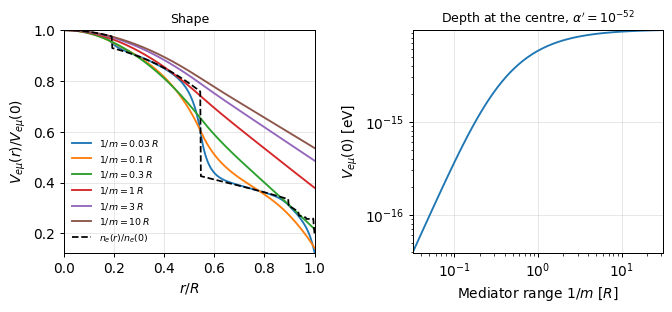

In [6]:
ranges = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
r_plot = np.linspace(0.0, R_E, 400)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
for k, f in enumerate(ranges):
    v = yukawa_potential(r_plot, R_EARTH_GRID, NE_EARTH,
                         1.0/(f*R_E), alpha_ref)
    axes[0].plot(r_plot/R_E, v/v[0], color="C%d" % k,
                 label=r"$1/m = %g\,R$" % f)
ne_plot = np.interp(r_plot, R_EARTH_GRID, NE_EARTH)
axes[0].plot(r_plot/R_E, ne_plot/ne_plot[0], "k--", lw=1.4,
             label=r"$n_e(r)/n_e(0)$")
axes[0].set_xlim(0.0, 1.0)
axes[0].set_xlabel("$r/R$")
axes[0].set_ylabel(r"$V_{e\mu}(r)/V_{e\mu}(0)$")
axes[0].set_title("Shape", fontsize=10)
axes[0].legend(fontsize=7.5)

spread = np.logspace(-1.5, 1.5, 60)
centre = np.array([yukawa_potential(
    np.array([0.0]), R_EARTH_GRID, NE_EARTH, 1.0/(f*R_E),
    alpha_ref)[0] for f in spread])
axes[1].loglog(spread, centre)
axes[1].set_xlim(spread[0], spread[-1])
axes[1].set_xlabel("Mediator range $1/m$ [$R$]")
axes[1].set_ylabel(r"$V_{e\mu}(0)$ [eV]")
axes[1].set_title(r"Depth at the centre, $\alpha'=10^{-52}$", fontsize=10)
fig.tight_layout()
plt.show()

The left panel is the whole argument in one picture. At $1/m = 0.03\,R$ the potential has very nearly taken the shape of the dashed density curve, shell jumps and all; by $1/m = 10\,R$ it has forgotten the profile entirely and is a smooth bowl. The right panel shows the crossover: $V_{e\mu}(0)$ grows as $1/m^2$ while the range is short and saturates once the mediator reaches across the body, because there are no more electrons to enclose.

Everything below uses $1/m = R$, one range per body, which is the awkward middle where neither limit applies.

## Profile 1: an invented body

A body of the Earth's radius with $\rho(r) = \rho_c\left[1-(r/R)^2\right]$, and $\rho_c$ chosen so that its **mean density, and so its total electron count, match the Earth's**. Nothing in the library knows this profile; `slabs.probabilities_3nu_profile` takes it as a callable.

Matching the electron count is what makes the comparison with PREM later worth making: the two bodies hold the same electrons, arranged differently.

In [7]:
RHO_C = 5.51/0.4            # <rho> = 0.4 rho_c for this shape
BODY_RADII = np.linspace(0.0, R_E, 4001)
BODY_RHO = RHO_C*(1.0 - (BODY_RADII/R_E)**2.0)
BODY_NE = n_e_of_density(BODY_RHO)

print("central density : %.3f g/cm^3" % RHO_C)
print("mean density    : %.3f g/cm^3"
      % (integral(BODY_RADII**2.0*BODY_RHO, BODY_RADII)
         / integral(BODY_RADII**2.0, BODY_RADII)))
print("electrons, relative to the Earth : %.4f"
      % (4.0*np.pi*integral(BODY_RADII**2.0*BODY_NE,
                            BODY_RADII)/N_E_EARTH))

central density : 13.775 g/cm^3
mean density    : 5.510 g/cm^3
electrons, relative to the Earth : 0.9995


### The callable

`hamiltonian_of(positions)` receives **all** the midpoints of a refinement at once, as distances along the trajectory in eV$^{-1}$, and must return one $3\times3$ Hamiltonian per position. Writing it vectorised is not an optimisation here: the routine calls it once per refinement, so a loop inside would be the only loop in the calculation.

The trajectory is a **diameter**, so the radius is $|x - R|$ — which is also why the potential it sees is symmetric about the midpoint, the same palindrome the compiled Earth kernels exploit.

In [8]:
def body_hamiltonian_of(energy_ev, alpha, m):
    """Builds the callable that `..._profile` wants."""
    def h_of(x):
        r = np.abs(x - R_E)                  # a diameter
        rho = RHO_C*(1.0 - (r/R_E)**2.0)
        h = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
            H_VAC_3NU, energy_ev, earth.matter_potential(rho)))
        if alpha:
            v = yukawa_potential(r, BODY_RADII, BODY_NE, m,
                                 alpha)
            h = h + v[:, None, None]*Q_LR
        return h
    return h_of


E_BODY = 1.5*GEV
M_BODY = 1.0/R_E

# No folklore exists about how many slabs an invented profile
# needs, which is exactly the argument for a tolerance.
for a in (0.0, 1.0e-52):
    p, n = slabs.probabilities_3nu_profile(
        body_hamiltonian_of(E_BODY, a, M_BODY), 2.0*R_E,
        rtol=1.0e-4, atol=1.0e-8, return_n_slabs=True)
    print("alpha' = %-8.0e n_slabs = %4d  P_mue = %.6f  sum = %.15f"
          % (a, n, p[3], sum(p[0:3])))

alpha' = 0e+00    n_slabs =  512  P_mue = 0.078152  sum = 1.000000000000472
alpha' = 1e-52    n_slabs =  512  P_mue = 0.059361  sum = 1.000000000000570


The probabilities still sum to one from each initial flavor, which is the first thing to check of any Hamiltonian you have built yourself: an algebra slip that breaks Hermiticity shows up here and nowhere else.

And the sampling is second-order, as it is for any profile — the midpoint rule does not care that the Hamiltonian is unfamiliar:

In [9]:
reference = np.array(slabs.probabilities_3nu_profile(
    body_hamiltonian_of(E_BODY, 1.0e-52, M_BODY), 2.0*R_E,
    n_slabs=8192))

previous = None
print("n_slabs   max error   order")
for n in (16, 32, 64, 128, 256):
    p = np.array(slabs.probabilities_3nu_profile(
        body_hamiltonian_of(E_BODY, 1.0e-52, M_BODY),
        2.0*R_E, n_slabs=n))
    err = np.max(np.abs(p - reference))
    print("%7d   %.3e   %s"
          % (n, err, "-" if previous is None
             else "%.2f" % np.log2(previous/err)))
    previous = err

n_slabs   max error   order
     16   3.017e-03   -
     32   5.457e-04   2.47
     64   1.276e-04   2.10
    128   3.139e-05   2.02
    256   7.811e-06   2.01


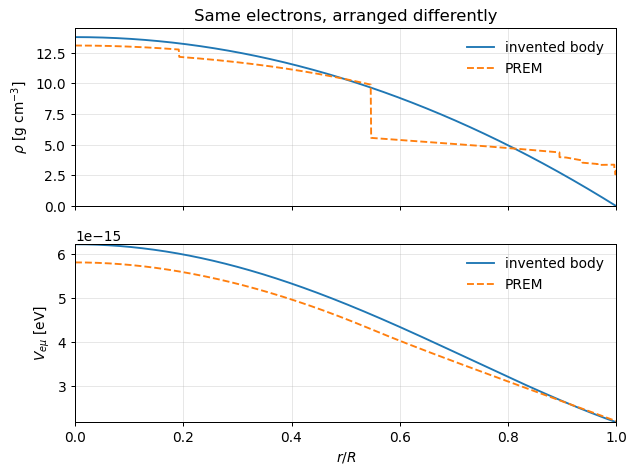

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.4),
                         sharex=True)
axes[0].plot(BODY_RADII/R_E, BODY_RHO, label="invented body")
axes[0].plot(R_EARTH_GRID/R_E,
             earth.density_prem(R_EARTH_GRID/KM), "--",
             label="PREM")
axes[0].set_ylabel(r"$\rho$ [g cm$^{-3}$]")
axes[0].set_ylim(0.0, 14.5)
axes[0].legend()
axes[0].set_title("Same electrons, arranged differently")

axes[1].plot(BODY_RADII/R_E, yukawa_potential(
    BODY_RADII, BODY_RADII, BODY_NE, M_BODY, alpha_ref),
    label="invented body")
axes[1].plot(R_EARTH_GRID/R_E, yukawa_potential(
    R_EARTH_GRID, R_EARTH_GRID, NE_EARTH, M_BODY, alpha_ref),
    "--", label="PREM")
axes[1].set_xlim(0.0, 1.0)
axes[1].set_xlabel("$r/R$")
axes[1].set_ylabel(r"$V_{e\mu}$ [eV]")
axes[1].legend()
fig.tight_layout()
plt.show()

In [11]:
v_body = yukawa_potential(BODY_RADII, BODY_RADII, BODY_NE,
                          M_BODY, alpha_ref)
v_prem = yukawa_potential(BODY_RADII, R_EARTH_GRID, NE_EARTH,
                          M_BODY, alpha_ref)
rho_prem = earth.density_prem(BODY_RADII[:-1]/KM)

print("largest ratio between the two densities  : %.2f"
      % np.max(BODY_RHO[:-1]/rho_prem))
print("largest ratio between the two potentials : %.3f"
      % np.max(v_body/v_prem))
print("at the surface: %.4e vs %.4e eV" % (v_body[-1],
                                          v_prem[-1]))

largest ratio between the two densities  : 1.74
largest ratio between the two potentials : 1.079
at the surface: 2.1807e-15 vs 2.2062e-15 eV


The two densities differ by nearly a factor of two through the middle of the body — PREM's core-mantle jump against a smooth parabola — while the potentials they source differ by under a tenth, and at the surface they agree to one part in a hundred. The coincidence is not luck: at the surface there is no exterior piece left, so the potential is fixed by the enclosed electron count, which is what was matched. For a massless mediator it would be exact.

That is the non-locality made quantitative. A long-range force is sensitive to how many electrons there are and only weakly to where they sit, which is the exact opposite of $V_{CC}$.

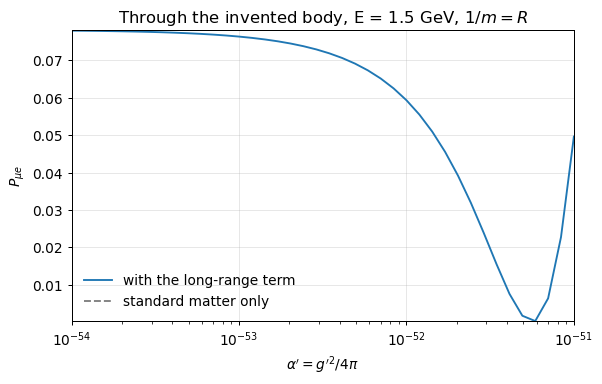

In [12]:
alphas = np.logspace(-54.0, -51.0, 40)
p_body = np.array([slabs.probabilities_3nu_profile(
    body_hamiltonian_of(E_BODY, a, M_BODY), 2.0*R_E,
    rtol=1.0e-4, atol=1.0e-8)[3] for a in alphas])
p_standard = slabs.probabilities_3nu_profile(
    body_hamiltonian_of(E_BODY, 0.0, M_BODY), 2.0*R_E,
    rtol=1.0e-4, atol=1.0e-8)[3]

fig, ax = plt.subplots()
ax.semilogx(alphas, p_body, label="with the long-range term")
ax.axhline(p_standard, color="0.5", ls="--",
           label="standard matter only")
ax.set_xlim(alphas[0], alphas[-1])
ax.set_xlabel(r"$\alpha' = g'^2/4\pi$")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Through the invented body, E = 1.5 GeV, "
             r"$1/m = R$")
ax.legend()
plt.show()

The left-hand end of that curve lies exactly on the standard-matter line, which is why the line looks missing: it is the $\alpha' \to 0$ check, and it passes.

What happens after that is not simple suppression. $P_{\mu e}$ falls by a factor of forty, bottoms out near $\alpha' = 6\times10^{-52}$, and climbs again — the extra splitting is re-tuning the interference between the slabs, and past the minimum a different oscillation is coming into phase. A bound built by assuming the effect is monotonic in the coupling would go wrong here, which is the sort of thing an exact calculation is for.

## Profile 2: an exponential body

A solar-like body: $\rho(r) = \rho_0 e^{-r/r_0}$ with $\rho_0 = 150$ g cm$^{-3}$ and $r_0 = R_\odot/10.54$, the same fit `14` uses, and the trajectory is a radius from the centre outward.

**How this differs from `14`.** That notebook asks what the *standard* Hamiltonian does in this profile, validates the slab calculation against the analytic adiabatic MSW result, and argues that a Magnus method is the better tool. All of that stands, and none of it is repeated here. What is new is that the Hamiltonian is no longer standard — and that the body is now interesting for a second reason. A long-range force integrates the whole object, so the Sun's enormous electron count matters in a way it does not for $V_{CC}$:

In [13]:
R_SUN_KM = 6.957e5
RHO_SUN_C = 150.0
R_SCALE_KM = R_SUN_KM/10.54
R_SUN = R_SUN_KM*KM

SUN_RADII = np.linspace(0.0, R_SUN, 8001)
SUN_NE = n_e_of_density(
    RHO_SUN_C*np.exp(-SUN_RADII/(R_SCALE_KM*KM)))
N_E_SUN = 4.0*np.pi*integral(SUN_RADII**2.0*SUN_NE, SUN_RADII)
V_CC_SUN_CENTRE = earth.matter_potential(RHO_SUN_C)

v_sun = yukawa_potential(np.array([0.0]), SUN_RADII, SUN_NE,
                         1.0/R_SUN, alpha_ref)[0]
v_earth = yukawa_potential(np.array([0.0]), R_EARTH_GRID,
                           NE_EARTH, 1.0/R_E, alpha_ref)[0]

print("central density, Sun / Earth's core : %.1f"
      % (RHO_SUN_C/earth.density_prem(0.0)))
print("electrons,      Sun / Earth         : %.3e"
      % (N_E_SUN/N_E_EARTH))
print("V_emu(0),       Sun / Earth         : %.0f"
      % (v_sun/v_earth))
print()
print("V_emu(0) at alpha' = 1e-52 : %.3e eV" % v_sun)
print("V_CC at the centre         : %.3e eV"
      % V_CC_SUN_CENTRE)

central density, Sun / Earth's core : 11.5
electrons,      Sun / Earth         : 1.812e+05
V_emu(0),       Sun / Earth         : 6946

V_emu(0) at alpha' = 1e-52 : 4.038e-11 eV
V_CC at the centre         : 5.679e-12 eV


Eleven times the central density, but seven thousand times the long-range potential. A local probe and a non-local one rank the two bodies completely differently, and that asymmetry is the reason long-range forces are hunted with astrophysical sources rather than in a laboratory.

In [14]:
def sun_hamiltonian_of(energy_ev, alpha, m):
    def h_of(x):
        r = np.minimum(x, R_SUN)             # a radius
        rho = RHO_SUN_C*np.exp(-r/(R_SCALE_KM*KM))
        h = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
            H_VAC_3NU, energy_ev,
            earth.matter_potential(rho)))
        if alpha:
            v = yukawa_potential(r, SUN_RADII, SUN_NE, m,
                                 alpha)
            h = h + v[:, None, None]*Q_LR
        return h
    return h_of


E_SUN = 1.0e7                        # 10 MeV
p, n_tol = slabs.probabilities_3nu_profile(
    sun_hamiltonian_of(E_SUN, 1.0e-54, 1.0/R_SUN), R_SUN,
    atol=1.0e-4, n_max=1 << 17, return_n_slabs=True)
print("atol = 1e-4 asks for %d slabs, and gives P_ee = %.6f"
      % (n_tol, p[0]))

atol = 1e-4 asks for 8192 slabs, and gives P_ee = 0.369148


Eight thousand slabs for one number — `14`'s wall, and it is unmoved by the extra term. But that number is also meaningless on its own, for `14`'s other reason: at 10 MeV the probability oscillates far faster than any detector, or any production region, resolves. The physical quantity is the average over a band, so that is what to plot against the coupling.

One practical note on tolerances, since it looks like a contradiction. The scan below fixes `n_slabs=4096`, half of what the tolerance search just asked for, because an *average* over two hundred energies tolerates more error per point than a single reported probability does — the errors are not correlated across the band. Checking that 4096 and 8192 give the same average is a two-line experiment and it is how that number was chosen.

In [15]:
def averaged_p_ee(alpha, n_slabs=4096, n_energies=200):
    """<P_ee> over a 2% band, on a fixed energy grid."""
    band = np.linspace(0.99e7, 1.01e7, n_energies)
    return np.mean([slabs.probabilities_3nu_profile(
        sun_hamiltonian_of(e, alpha, 1.0/R_SUN), R_SUN,
        n_slabs=n_slabs)[0] for e in band])


# The analytic adiabatic MSW result, as in notebook 14, with
# the three-flavor cos^4(theta13) correction.
cos2th = 1.0 - 2.0*gd.S12_NO_BF**2.0
x = 2.0*E_SUN*V_CC_SUN_CENTRE/gd.D21_NO_BF
cos2th_m = (cos2th-x)/np.sqrt((cos2th-x)**2.0
                              + (1.0-cos2th**2.0))
c13sq = 1.0 - gd.S13_NO_BF**2.0
p_adiabatic = (c13sq**2.0*0.5*(1.0 + cos2th_m*cos2th)
               + gd.S13_NO_BF**4.0)

p_sun_standard = averaged_p_ee(0.0)
print("adiabatic MSW, with the c13^4 correction : %.4f"
      % p_adiabatic)
print("slabs, averaged, standard matter         : %.4f"
      % p_sun_standard)

# The claim that 4096 slabs is enough for an average,
# checked rather than asserted -- and the second line
# measures how much of the residual above is nothing but
# the finite sampling of the band.
print("the same average at 8192 slabs           : %.4f"
      % averaged_p_ee(0.0, n_slabs=8192))
print("at 4096 slabs but half the energies      : %.4f"
      % averaged_p_ee(0.0, n_energies=100))

adiabatic MSW, with the c13^4 correction : 0.3365
slabs, averaged, standard matter         : 0.3413


the same average at 8192 slabs           : 0.3413
at 4096 slabs but half the energies      : 0.3386


The slab count is settled: 4096 and 8192 agree to the fourth decimal, so the discretisation is not what limits this. Halving the number of energies instead moves the average by a few parts in a thousand, comparable to the remaining gap to the analytic value — so the calculation agrees with the adiabatic MSW prediction as closely as a two-hundred-point sampling of the band can show, reproducing `14`'s two-flavor validation with the $\theta_{13}$ correction included. The machinery is right, so what it says about the new term can be believed.

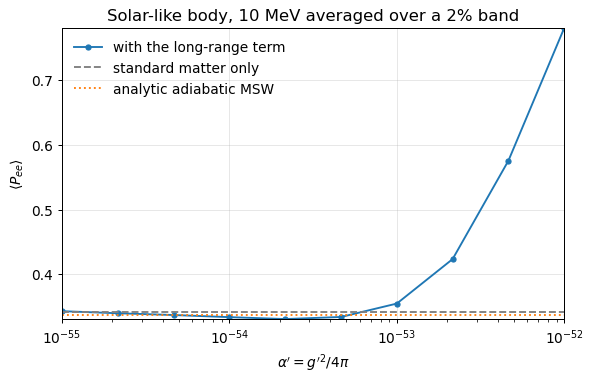

In [16]:
alphas_sun = np.logspace(-55.0, -52.0, 10)
p_sun = np.array([averaged_p_ee(a) for a in alphas_sun])

fig, ax = plt.subplots()
ax.semilogx(alphas_sun, p_sun, "o-", ms=4,
            label="with the long-range term")
ax.axhline(p_sun_standard, color="0.5", ls="--",
           label="standard matter only")
ax.axhline(p_adiabatic, color="C1", ls=":",
           label="analytic adiabatic MSW")
ax.set_xlim(alphas_sun[0], alphas_sun[-1])
ax.set_xlabel(r"$\alpha' = g'^2/4\pi$")
ax.set_ylabel(r"$\langle P_{ee} \rangle$")
ax.set_title("Solar-like body, 10 MeV averaged over a 2% band")
ax.legend()
plt.show()

The average is far less sensitive than a single energy: it is flat until $\alpha' \approx 5\times10^{-54}$, where $V_{e\mu}$ at the centre reaches about a third of $V_{CC}$ there, and only then does the resonance move enough to survive the averaging. That is worth stating plainly, because a single-energy calculation would suggest a reach roughly an order of magnitude better than the averaged one actually delivers.

The direction is the physics. $\langle P_{ee}\rangle$ does not drift toward the vacuum-averaged value — it climbs past it, toward one. A large $V_{e\mu}$ dominates the $e$–$\mu$ block and makes $\nu_e$ very nearly an eigenstate, so the MSW conversion is not merely detuned but switched off.

**On the coupling values.** They are chosen to make the figures show something, exactly as `03`'s NSI and LIV parameters are. Nothing here is a bound: a bound needs a real source spectrum, a detector response, and the rest of the Universe's electrons, which the reference has and this notebook does not.

## Profile 3: the Earth

And now the one that needs care. `earth.probabilities_3nu_earth` takes the energy-independent **vacuum** Hamiltonian and builds $H = H_{\rm vac}/E + V_{CC} P_{ee}$ per slab itself. There is no argument to it that produces our extra term, so the convenience of a single call is not available. The path is four lines, and it is the honest answer to "how do I put *my* Hamiltonian through the Earth":

```python
widths_km, densities = earth.earth_slabs(costhz, n_per_segment)
potentials = earth.matter_potential(densities)
h = your_own_construction(potentials)      # (n_slabs, 3, 3)
slabs.probabilities_3nu_slabs(h, widths_km*KM)
```

`earth_slabs` does the part worth reusing — it cuts the chord at every PREM boundary it crosses, so no slab straddles a discontinuity — and hands back widths and densities you are free to interpret. The radius at each slab midpoint, which the new potential needs and the standard one does not, comes from `earth_radial_distance_from_depth`.

In [17]:
def earth_chord(costhz, energy_ev, alpha, m,
                n_per_segment=8):
    """The nine probabilities along one chord."""
    widths_km, densities = earth.earth_slabs(costhz,
                                             n_per_segment)
    h = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, energy_ev,
        earth.matter_potential(densities)))

    if alpha:
        edges = np.concatenate(([0.0], np.cumsum(widths_km)))
        mid_km = 0.5*(edges[:-1]+edges[1:])
        r_mid = earth.earth_radial_distance_from_depth(
            costhz, mid_km)*KM
        v = yukawa_potential(r_mid, R_EARTH_GRID, NE_EARTH,
                             m, alpha)
        h = h + v[:, None, None]*Q_LR

    return np.array(slabs.probabilities_3nu_slabs(
        h, widths_km*KM))


# Switch the new term off and this must reproduce the
# library's own Earth routine.  Not "to within a tolerance":
# it is the same construction, so it is the same arithmetic.
worst = 0.0
for cz in (-1.0, -0.8, -0.35, -0.05):
    for e_gev in (1.0, 5.0, 10.0, 50.0):
        mine = earth_chord(cz, e_gev*GEV, 0.0, 0.0)
        theirs = np.array(earth.probabilities_3nu_earth(
            H_VAC_3NU, e_gev*GEV, cz))
        worst = max(worst, np.max(np.abs(mine-theirs)))
print("max |difference| over 16 (angle, energy) pairs: %.1e"
      % worst)

max |difference| over 16 (angle, energy) pairs: 0.0e+00


Zero. The recipe is not an approximation to the library's Earth routine, it *is* the library's Earth routine with the Hamiltonian construction pulled out into the open — which is the only reason it is safe to add a term to.

### How finely to cut the chord

`earth.slabs_for_tolerance` sizes the subdivision for a given accuracy, but it sizes it for the *standard* Hamiltonian, since that is the only one it can build. It is still the right starting point — the new potential is smooth on the scale of a PREM shell, so it asks less of the discretisation than the density jumps do — and the way to confirm that is to double the subdivision and watch the answer not move.

In [18]:
E_SCAN = np.logspace(0.0, 2.0, 300)*GEV
ALPHA_EARTH = 1.0e-52
M_EARTH = 1.0/R_E

n_per = earth.slabs_for_tolerance(H_VAC_3NU, E_SCAN, -1.0,
                                  rtol=1.0e-3)
print("slabs_for_tolerance, rtol 1e-3 : %d per segment"
      % n_per)

coarse = earth_chord(-1.0, 10.0*GEV, ALPHA_EARTH, M_EARTH,
                     n_per_segment=n_per)
fine = earth_chord(-1.0, 10.0*GEV, ALPHA_EARTH, M_EARTH,
                   n_per_segment=2*n_per)
print("doubling it moves the nine probabilities by %.2e"
      % np.max(np.abs(coarse-fine)))

slabs_for_tolerance, rtol 1e-3 : 128 per segment
doubling it moves the nine probabilities by 5.48e-07


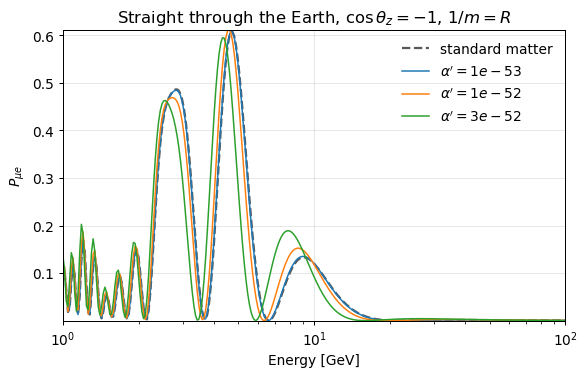

In [19]:
fig, ax = plt.subplots()
for a in (0.0, 1.0e-53, 1.0e-52, 3.0e-52):
    p = np.array([earth_chord(-1.0, e, a, M_EARTH,
                              n_per_segment=n_per)[3]
                  for e in E_SCAN])
    ax.semilogx(E_SCAN/GEV, p,
                lw=1.8 if a == 0.0 else 1.2,
                ls="--" if a == 0.0 else "-",
                color="0.35" if a == 0.0 else None,
                label="standard matter" if a == 0.0
                else r"$\alpha' = %.0e$" % a)
ax.set_xlim(E_SCAN[0]/GEV, E_SCAN[-1]/GEV)
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Straight through the Earth, "
             r"$\cos\theta_z = -1$, $1/m = R$")
ax.legend()
plt.show()

The long-range term adds to the $e$–$\mu$ splitting, so it bites where that splitting is comparable to the vacuum one: between roughly 2 and 10 GeV it shifts and reshapes the resonance structure, moving the main peak and lifting the shoulder above it. Above about 20 GeV nothing happens, and for a reason worth keeping: there the standard matter term already dominates and has already suppressed the transition, so one more diagonal term changes nothing.

Note also what is *not* happening. Even at $\alpha' = 3\times10^{-52}$ the peak is displaced rather than destroyed — the effect is a rearrangement of where the oscillation sits, not an overall damping.

Every direction at once shows where the sensitivity actually lives. This is an oscillogram of the *difference*, and each point of it is a separate hand-built chord — one call per point, because the batched entry points build the standard Hamiltonian and cannot be borrowed here. It is the one place where declining the library's Earth routine has a real cost.

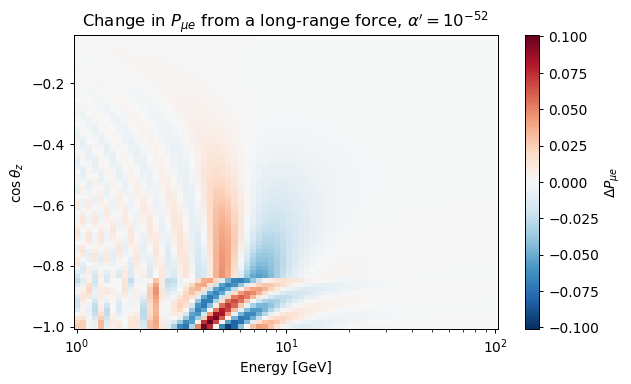

In [20]:
cz_grid = np.linspace(-1.0, -0.05, 70)
e_grid = np.logspace(0.0, 2.0, 70)*GEV

shift = np.array([
    [earth_chord(cz, e, ALPHA_EARTH, M_EARTH,
                 n_per_segment=n_per)[3]
     - earth_chord(cz, e, 0.0, 0.0, n_per_segment=n_per)[3]
     for e in e_grid] for cz in cz_grid])

fig, ax = plt.subplots(figsize=(7.2, 4.4))
limit = np.max(np.abs(shift))
mesh = ax.pcolormesh(e_grid/GEV, cz_grid, shift,
                     cmap="RdBu_r", vmin=-limit, vmax=limit,
                     shading="auto")
ax.set_xscale("log")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$\cos\theta_z$")
ax.set_title(r"Change in $P_{\mu e}$ from a long-range "
             r"force, $\alpha' = 10^{-52}$")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$\Delta P_{\mu e}$")
fig.tight_layout()
plt.show()

The signal is confined to the long chords and to a few GeV — core-crossing trajectories, where both the path and the enclosed electron count are largest. Short chords barely enter the body and see a small fraction of it.

## Putting your own Hamiltonian through this

Nothing above is specific to a long-range force. The pattern is the same whatever the extra term is:

1. **Write the matrix.** Any $3\times3$ Hermitian addition to $H_{\rm vac}/E + V_{CC}P_{ee}$ will do. Only the traceless part matters (`01`), so a flavor-universal piece can be dropped — and if it is enormous, it *should* be, or it will eat the significant digits of the physics.
2. **For a body, use `slabs.probabilities_{2,3,4}nu_profile`** with a vectorised callable, and let `rtol`/`atol` choose the subdivision. An invented profile has no folklore about how many slabs it needs.
3. **For the Earth, use `earth.earth_slabs`** and hand the result to `slabs.probabilities_3nu_slabs` yourself. The boundary cuts are the part worth reusing; the Hamiltonian is yours.
4. **Check it.** Probabilities sum to one from every initial flavor; switching the new term off must reproduce the standard routine exactly; and the discretisation must converge at second order. All three are cheap, and all three were run above.

Where the profile varies smoothly over many oscillation lengths, `14`'s advice still applies and applies here too: the slab count is set by the oscillation, not by the Hamiltonian, and a Magnus-type method is the better tool. The extra term changes none of that.

---

**Previous:** [Animated scenes](19_animations.ipynb)  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)